In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, FancyArrowPatch

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'vmatplot').is_dir())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from vmatplot.topology_figures import STYLES
from vmatplot.output_settings import LINE_WIDTH, color_sampling

plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm',
                     'pdf.fonttype': 42, 'figure.facecolor': 'white',
                     'lines.linewidth': LINE_WIDTH, 'patch.linewidth': LINE_WIDTH,
                     'lines.solid_capstyle': 'round', 'lines.solid_joinstyle': 'round',
                     'path.simplify': False})


In [2]:
def plot_brillouin_zone(version='thesis'):
    style = dict(STYLES[version])
    style.update(label=18 if version == 'thesis' else 20, panel=15 if version == 'thesis' else 20)
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 4) if version == 'thesis' else (12.9, 6),
                             gridspec_kw={'width_ratios': [2.44, 2.80]})
    fig.subplots_adjust(left=.025, right=.975, bottom=.025, top=.975, wspace=.06)
    h = np.sqrt(3) / 2
    vertices = np.array([[0, 1], [h, .5], [h, -.5], [0, -1], [-h, -.5], [-h, .5]])
    blue, red, green = color_sampling('Blue')[1], color_sampling('Red')[1], color_sampling('Cyan')[1]
    titles = ['(a) Hexagonal cells', '(b) Distorted hexagonal cells']
    for ax, title, xlim in zip(axes, titles, [(-1.22, 1.22), (-1.22, 1.58)]):
        ax.set(xlim=xlim, ylim=(-1.15, 1.78), aspect='equal')
        ax.axis('off')
        ax.add_patch(Polygon(vertices, closed=True, fill=False, edgecolor='black', linewidth=LINE_WIDTH, joinstyle='round'))
        ax.text(.015, .975, title, transform=ax.transAxes, va='top', fontsize=style['panel'],
                bbox=dict(boxstyle='round', facecolor='white', edgecolor='lightgrey', alpha=.75), zorder=8)

    def label(ax, point, text, offset, ha='left', va='center', size=None):
        ax.annotate(text, point, xytext=offset, textcoords='offset points',
                    ha=ha, va=va, fontsize=style['label'] if size is None else size)

    arrow_style = dict(arrowstyle='-|>', mutation_scale=14 if version == 'thesis' else 18,
                       linewidth=LINE_WIDTH, capstyle='round', joinstyle='round',
                       shrinkA=0, shrinkB=0, rasterized=False)

    def arrow(ax, start, end, color='black'):
        ax.add_patch(FancyArrowPatch(start, end, color=color, zorder=4, **arrow_style))

    ax = axes[0]
    ax.add_patch(Polygon(vertices, closed=True, facecolor=blue, edgecolor='none', alpha=.08, zorder=0))
    ax.plot([-1.15, 1.15], [0, 0], color='black')
    ax.plot([0, 0], [-1.12, 1.17], color='black')
    ax.plot([0, 1.03], [0, 1.03 / np.sqrt(3)], color='black')
    for point, text, offset, ha, va in [((0, 0), r'$\Gamma$', (-5, -6), 'right', 'top'),
            ((h, 0), 'M', (5, -5), 'left', 'top'), ((h, .5), 'K', (0, 7), 'center', 'bottom')]:
        ax.plot(*point, marker='o', ms=5, mfc=blue, mec='black', mew=LINE_WIDTH, zorder=5)
        label(ax, point, text, offset, ha, va)

    ax = axes[1]
    # Points of the phonon and band paths, in units of b1 (0°) and b2 (60°): X = b1/2, Y = b2/2 and M′ = (b2 - b1)/2 lie on
    # the zone boundary; M = (b1 + b2)/2 lies outside the first zone, on the line Γ–K, and is equivalent to M′
    b1, b2 = np.array([2*h, 0]), np.array([h, 1.5])
    gamma, x, y, m, m1 = np.zeros(2), b1/2, b2/2, (b1 + b2)/2, (b2 - b1)/2
    for vector, index in [(b1, '1'), (b2, '2')]:
        end = vector*.72
        arrow(ax, gamma, end)
        symbol = r'\vec{b}_' if version == 'thesis' else r'\mathbf{b}_'
        label(ax, end, '$' + symbol + index + '$', (3, 0), 'left', 'center', size=style['label'] + (4 if version == 'thesis' else 6))
    for start, end in [(gamma, x), (x, m), (m, gamma)]:
        arrow(ax, start, end, red)
    for start, end in [(gamma, y), (y, m1), (m1, gamma)]:
        arrow(ax, start, end, green)
    for point, text, offset, ha, va in [(gamma, r'$\Gamma$', (-5, -6), 'right', 'top'),
            (x, 'X', (-4, -6), 'right', 'top'), (m, 'M', (6, 0), 'left', 'center'),
            (y, 'Y', (-4, 5), 'right', 'bottom'), (m1, r'M$^{\prime}$', (-5, 6), 'right', 'bottom')]:
        label(ax, point, text, offset, ha, va)
    return fig


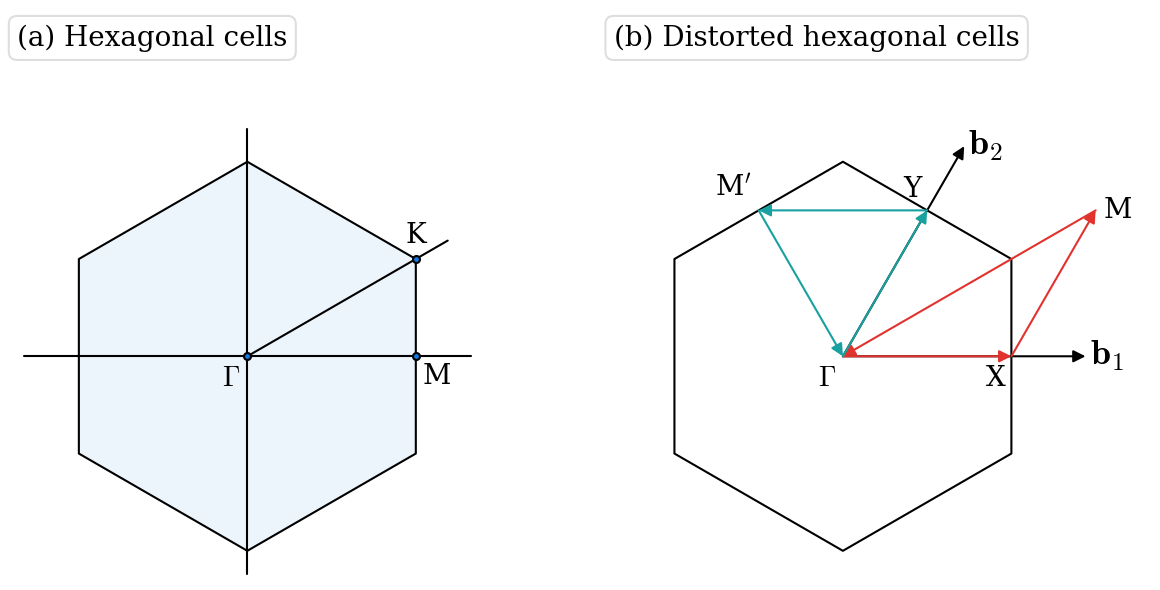

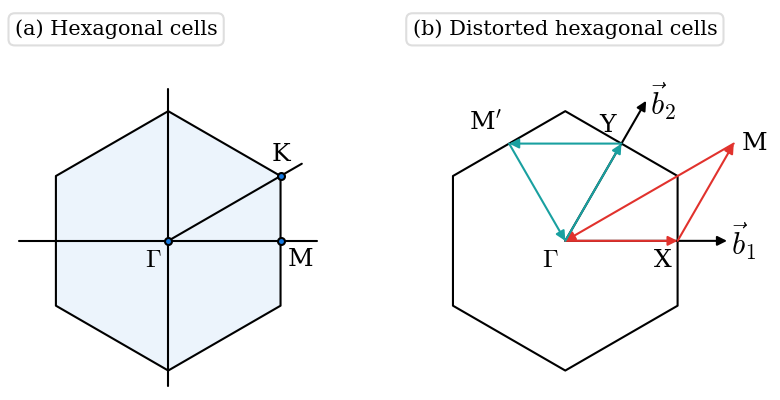

In [3]:
for version in ('article', 'thesis'):
    fig = plot_brillouin_zone(version)
    suffix = '_thesis' if version == 'thesis' else ''
    fig.savefig(root / 'figures' / f'brillouin_zone{suffix}.pdf', metadata={'CreationDate': None})
    plt.show()
